In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('../Datasets/windspeed_datasets.csv')
df.head()

,_id,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,...,River,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Telemetry Hourly Wind Speed (Km/Hr)
0,1,1,Aralvaimozhi,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,Thovalai,-,...,-,-,-,-,-,-,8.247222,77.545,15-12-2021 17:00,2.4
1,2,2,Aralvaimozhi,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,Thovalai,-,...,-,-,-,-,-,-,8.247222,77.545,15-12-2021 18:00,1.0
2,3,3,Aralvaimozhi,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,Thovalai,-,...,-,-,-,-,-,-,8.247222,77.545,15-12-2021 19:00,1.7
3,4,4,Aralvaimozhi,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,Thovalai,-,...,-,-,-,-,-,-,8.247222,77.545,16-12-2021 10:00,4.3
4,5,5,Aralvaimozhi,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,Thovalai,-,...,-,-,-,-,-,-,8.247222,77.545,16-12-2021 11:00,5.5


In [3]:
df.shape

(1598990, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1598990 entries, 0 to 1598989
Data columns (total 21 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   _id                                  1598990 non-null  int64  
 1   SlNo                                 1598990 non-null  int64  
 2   Station                              1598990 non-null  object 
 3   Agency                               1598990 non-null  object 
 4   State LGD Code                       1598990 non-null  int64  
 5   State                                1598990 non-null  object 
 6   District LGD Code                    1598990 non-null  int64  
 7   District                             1598990 non-null  object 
 8   Tehsil                               1598990 non-null  object 
 9   Block                                1598990 non-null  object 
 10  Village                              1598990 non-null  object 
 11

In [5]:
df=df[["Data Acquisition Time","Telemetry Hourly Wind Speed (Km/Hr)"]]
df.shape

(1598990, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1598990 entries, 0 to 1598989
Data columns (total 2 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   Data Acquisition Time                1598990 non-null  object 
 1   Telemetry Hourly Wind Speed (Km/Hr)  1598990 non-null  float64
dtypes: float64(1), object(1)
memory usage: 24.4+ MB


In [7]:
df["Data Acquisition Time"]

0          15-12-2021 17:00
1          15-12-2021 18:00
2          15-12-2021 19:00
3          16-12-2021 10:00
4          16-12-2021 11:00
                 ...       
1598985    31-12-2025 19:00
1598986    31-12-2025 20:00
1598987    31-12-2025 21:00
1598988    31-12-2025 22:00
1598989    31-12-2025 23:00
Name: Data Acquisition Time, Length: 1598990, dtype: object

In [8]:
df["Data Acquisition Time"]=pd.to_datetime(
    df["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M"
)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1598990 entries, 0 to 1598989
Data columns (total 2 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   Data Acquisition Time                1598990 non-null  datetime64[ns]
 1   Telemetry Hourly Wind Speed (Km/Hr)  1598990 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 24.4 MB


In [10]:
min(df["Data Acquisition Time"])

Timestamp('2000-01-01 00:05:00')

In [11]:
df=df[df["Data Acquisition Time"]>= "2015-01-01"]

In [12]:
(df["Data Acquisition Time"].min())

Timestamp('2017-12-17 07:00:00')

In [13]:
df.shape

(1597398, 2)

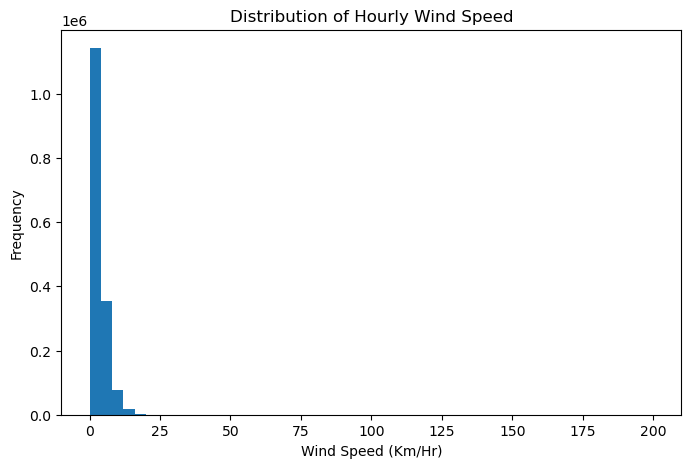

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Telemetry Hourly Wind Speed (Km/Hr)"], bins=50)
plt.xlabel("Wind Speed (Km/Hr)")
plt.ylabel("Frequency")
plt.title("Distribution of Hourly Wind Speed")
plt.show()

In [15]:
print(df["Telemetry Hourly Wind Speed (Km/Hr)"].describe())

print("Skewness:",
      df["Telemetry Hourly Wind Speed (Km/Hr)"].skew())

count    1.597398e+06
mean     3.438032e+00
std      7.265690e+00
min      0.000000e+00
25%      1.200000e+00
50%      2.400000e+00
75%      4.300000e+00
max      2.000000e+02
Name: Telemetry Hourly Wind Speed (Km/Hr), dtype: float64
Skewness: 17.97928493685301


In [16]:
(df["Telemetry Hourly Wind Speed (Km/Hr)"] > 50).mean() * 100

0.21115589226980377

In [17]:
df[df["Telemetry Hourly Wind Speed (Km/Hr)"] > 100]

,Data Acquisition Time,Telemetry Hourly Wind Speed (Km/Hr)
926754,2022-03-04 14:25:00,164.0
926755,2022-03-04 15:00:00,164.0
926756,2022-03-04 16:00:00,164.0
926757,2022-03-04 17:00:00,163.0
926758,2022-03-04 18:00:00,163.0
...,...,...
929949,2022-09-29 09:00:00,159.0
929950,2022-09-29 10:00:00,160.0
930593,2022-11-14 12:30:00,200.0
930594,2022-11-14 12:35:00,200.0


In [18]:
# Find the row containing the maximum wind speed
max_row = df.loc[df["Telemetry Hourly Wind Speed (Km/Hr)"].idxmax()]

print(max_row)

Data Acquisition Time                  2022-07-26 08:00:00
Telemetry Hourly Wind Speed (Km/Hr)                  200.0
Name: 928712, dtype: object


In [19]:
max_speed = df["Telemetry Hourly Wind Speed (Km/Hr)"].max()

df[df["Telemetry Hourly Wind Speed (Km/Hr)"] == max_speed].head(30)

,Data Acquisition Time,Telemetry Hourly Wind Speed (Km/Hr)
928712,2022-07-26 08:00:00,200.0
928713,2022-07-26 09:00:00,200.0
928714,2022-07-26 10:00:00,200.0
928715,2022-07-26 11:00:00,200.0
928716,2022-07-26 12:00:00,200.0
928717,2022-07-26 13:00:00,200.0
928718,2022-07-26 14:00:00,200.0
928719,2022-07-26 15:00:00,200.0
928720,2022-07-26 16:00:00,200.0
928721,2022-07-26 17:00:00,200.0


In [22]:
df.head()

,Data Acquisition Time,Telemetry Hourly Wind Speed (Km/Hr)
0,2021-12-15 17:00:00,2.4
1,2021-12-15 18:00:00,1.0
2,2021-12-15 19:00:00,1.7
3,2021-12-16 10:00:00,4.3
4,2021-12-16 11:00:00,5.5


In [23]:
df.to_csv(r"D:\Final Year Project 2027\Electricity Demand and Supply Forecasting\Datasets\windspeed_datasets.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!
